In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import pymc as pm
import arviz as az
import pytensor.tensor as pt

from sklearn.metrics import mean_squared_error, r2_score

step2:Load and inspect the data

In [2]:
df = pd.read_csv("C:\datasets\MMM_test_data.csv")

# the data is already pretty clean i have done only light processessing 
df["start_of_week"] = pd.to_datetime(df["start_of_week"], format="%d-%m-%y")
df = df.sort_values("start_of_week").reset_index(drop=True)

print(df.shape)
df.head()

(104, 9)


,start_of_week,revenue,spend_channel_1,spend_channel_2,spend_channel_3,spend_channel_4,spend_channel_5,spend_channel_6,spend_channel_7
0,2020-08-30,157906.75,2625.48,262.71,12954.12,3609.63,12955.29,12659.12,19379.79
1,2020-09-06,186425.68,2634.01,108.66,8760.28,4560.60,12747.70,12338.18,22473.45
2,2020-09-13,161607.39,2087.08,110.32,7155.42,4362.96,15015.41,10811.15,22596.05
3,2020-09-20,180089.13,1690.70,52.79,15185.22,3883.41,15521.41,12890.22,24728.73
4,2020-09-27,217793.98,1547.30,80.56,18524.05,4043.09,15793.74,12642.55,26515.48


step3:Quick quality checks

In [3]:
print("Missing values:")
print(df.isna().sum(), "\n")

print("Any duplicated rows?", df.duplicated().any())

Missing values:
start_of_week      0
revenue            0
spend_channel_1    0
spend_channel_2    0
spend_channel_3    0
spend_channel_4    0
spend_channel_5    0
spend_channel_6    0
spend_channel_7    0
dtype: int64 

Any duplicated rows? False


Key Takeaways

- This analysis uses a Bayesian Marketing Mix Model to estimate how each channel contributes to weekly revenue.
- The model includes adstock, so it can capture the delayed effect of marketing spend.
- In addition to model fitting, the notebook also looks at business-facing questions such as campaign lift and post-campaign carryover.
- The final outputs include channel contributions, ROI estimates, and a comparison of revenue before, during, and after the campaign.

step4:Identify channel columns

In [4]:
channel_cols = [col for col in df.columns if col.startswith("spend_channel_")]
channel_cols

['spend_channel_1',
 'spend_channel_2',
 'spend_channel_3',
 'spend_channel_4',
 'spend_channel_5',
 'spend_channel_6',
 'spend_channel_7']

# overview

In [5]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
start_of_week,104,2021-08-25 12:00:00,2020-08-30 00:00:00,2021-02-26 06:00:00,2021-08-25 12:00:00,2022-02-21 18:00:00,2022-08-21 00:00:00,NaN
revenue,104.0,136490.190673,63207.09,101675.685,128790.46,157707.28,418186.38,50810.253012
spend_channel_1,104.0,1245.604808,0.0,334.275,856.87,1658.0325,8513.83,1388.384632
spend_channel_2,104.0,343.640962,4.37,120.47,202.02,553.075,1605.85,332.988218
spend_channel_3,104.0,19507.177981,5938.13,13879.0,17929.45,22252.2625,49689.38,8714.759886
spend_channel_4,104.0,6915.136731,3602.2,5113.9375,6194.4,7470.5575,22629.69,3123.172035
spend_channel_5,104.0,8575.611442,747.46,2902.0325,6879.27,14367.5825,33009.65,6956.787524
spend_channel_6,104.0,5063.699038,0.0,0.0,2423.095,8701.96,33692.83,6689.47266
spend_channel_7,104.0,27701.367404,9391.21,19797.71,24248.64,33852.6525,77488.42,12176.293684


step5:Plot revenue over time

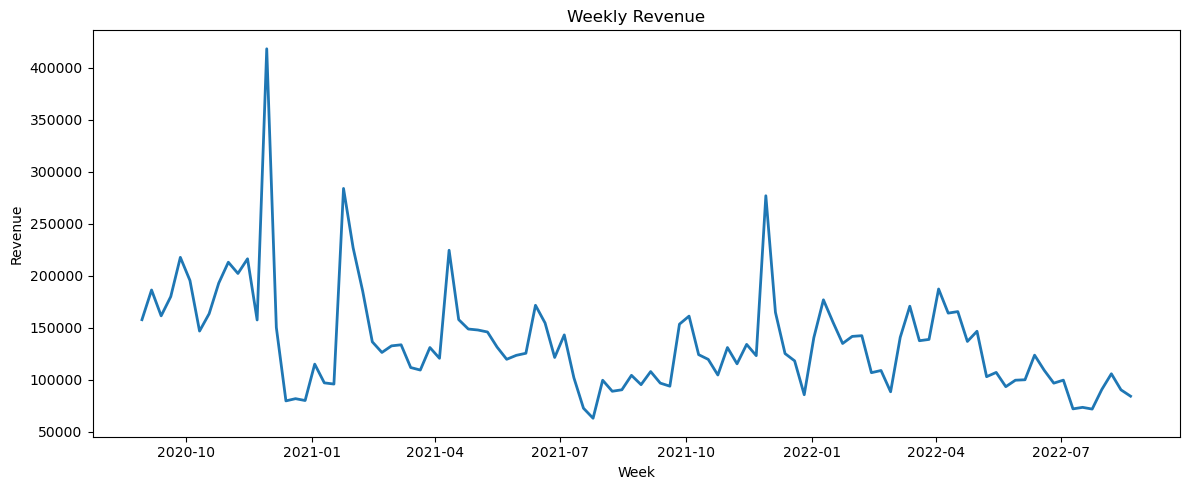

In [6]:
plt.figure(figsize=(12, 5))
plt.plot(df["start_of_week"], df["revenue"], linewidth=2)
plt.title("Weekly Revenue")
plt.xlabel("Week")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

Takeaway
This plot gives a quick view of how revenue changes over time.  
It is useful for checking whether there is a visible trend, seasonality, or any unusual spikes that the model may need to explain.

step6: Plot spend by channel

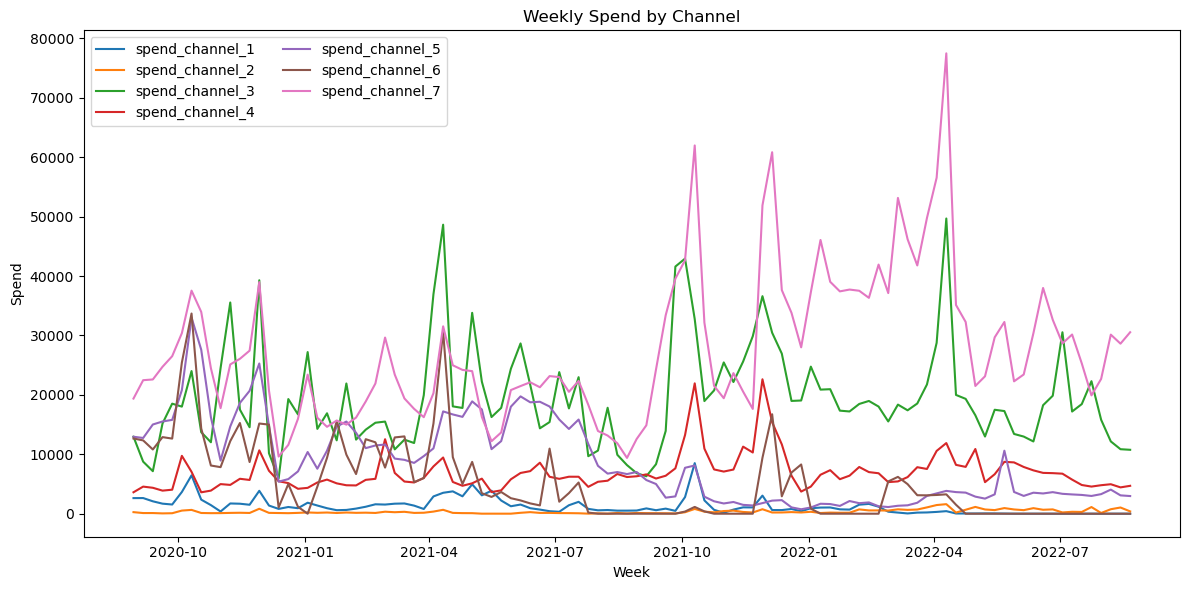

In [7]:
channel_cols = [col for col in df.columns if col.startswith("spend_channel_")]

plt.figure(figsize=(12, 6))
for col in channel_cols:
    plt.plot(df["start_of_week"], df[col], label=col)

plt.title("Weekly Spend by Channel")
plt.xlabel("Week")
plt.ylabel("Spend")
plt.legend(ncol=2)
plt.tight_layout()
plt.show()

step7: Correlation heatmap

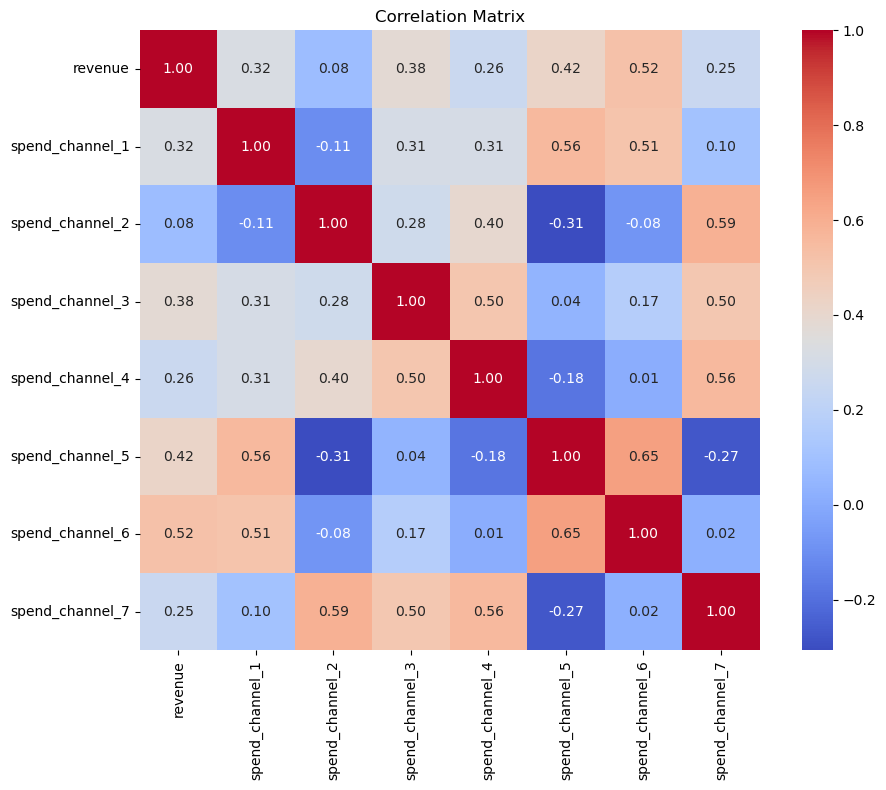

In [8]:
plt.figure(figsize=(10, 8))
corr = df.drop(columns="start_of_week").corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

step8: Add trend and seasonality features


In [9]:
df["trend"] = np.arange(len(df))

df["sin_52"] = np.sin(2 * np.pi * df["trend"] / 52)
df["cos_52"] = np.cos(2 * np.pi * df["trend"] / 52)

step9: Scale the media inputs a bit.
I usually like to scale channel spend by its mean.
This keeps values on a more manageable scale without losing interpretability.

In [10]:
spend_raw = df[channel_cols].copy()
spend_scale = spend_raw.mean()

spend_scaled = spend_raw / spend_scale
spend_scaled.head()

,spend_channel_1,spend_channel_2,spend_channel_3,spend_channel_4,spend_channel_5,spend_channel_6,spend_channel_7
0,2.107795,0.764490,0.664069,0.521990,1.510713,2.499975,0.699597
1,2.114643,0.316202,0.449080,0.659510,1.486506,2.436594,0.811276
2,1.675556,0.321033,0.366810,0.630929,1.750943,2.135030,0.815702
3,1.357333,0.153620,0.778443,0.561581,1.809948,2.545613,0.892690
4,1.242208,0.234431,0.949602,0.584672,1.841704,2.496702,0.957190


step10: Standardize revenue

In [11]:
y = df["revenue"].values
y_mean = y.mean()
y_std = y.std()

y_scaled = (y - y_mean) / y_std

step11: Build lagged media matrix for adstock.Instead of fixing adstock by hand, I want to let the model learn the carryover per channel.
I’ll use an 8-week lag window, which is a reasonable choice for weekly marketing data.

In [12]:
def make_lagged_matrix(media_df, max_lag=8):
    """
    Returns an array of shape:
    (n_observations, n_channels, max_lag)
    
    lag 0 = current week
    lag 1 = previous week
    ...
    """
    values = media_df.values
    n_obs, n_channels = values.shape
    
    lagged = np.zeros((n_obs, n_channels, max_lag))
    
    for t in range(n_obs):
        for lag in range(max_lag):
            if t - lag >= 0:
                lagged[t, :, lag] = values[t - lag, :]
    
    return lagged

max_lag = 8
lagged_media = make_lagged_matrix(spend_scaled, max_lag=max_lag)

lagged_media.shape

(104, 7, 8)

step 12:Prepare the remaining model inputs

In [13]:
trend = df["trend"].values
trend_scaled = (trend - trend.mean()) / trend.std()

seasonality = df[["sin_52", "cos_52"]].values
n_channels = len(channel_cols)

# Build the Bayesian MMM

In [14]:
with pm.Model() as mmm_model:
    
    # data containers
    media_data = pm.Data("media_data", lagged_media)
    trend_data = pm.Data("trend_data", trend_scaled)
    season_data = pm.Data("season_data", seasonality)
    
    # baseline revenue
    intercept = pm.Normal("intercept", mu=0, sigma=1)
    
    # channel-specific carryover / decay
    alpha = pm.Beta("alpha", alpha=2, beta=2, shape=n_channels)
    
    # positive media effect
    beta = pm.HalfNormal("beta", sigma=1, shape=n_channels)
    
    # controls
    trend_coef = pm.Normal("trend_coef", mu=0, sigma=0.5)
    season_coef = pm.Normal("season_coef", mu=0, sigma=0.5, shape=2)
    
    # adstock weights
    lag_idx = pt.arange(max_lag)
    raw_weights = alpha[:, None] ** lag_idx[None, :]
    norm_weights = raw_weights / raw_weights.sum(axis=1, keepdims=True)
    
    # apply adstock
    adstocked_media = (media_data * norm_weights[None, :, :]).sum(axis=2)
    
    # expected revenue
    mu = (
        intercept
        + pt.dot(adstocked_media, beta)
        + trend_coef * trend_data
        + pt.dot(season_data, season_coef)
    )
    
    sigma = pm.HalfNormal("sigma", sigma=1)
    
    revenue_like = pm.Normal("revenue_like", mu=mu, sigma=sigma, observed=y_scaled)
    
    # prior predictive
    prior_pred = pm.sample_prior_predictive(samples=500, random_seed=42)
    
    # posterior
    trace = pm.sample(
        draws=2000,
        tune=2000,
        target_accept=0.95,
        chains=4,
        random_seed=42
    )
    
    # posterior predictive
    posterior_pred = pm.sample_posterior_predictive(trace, random_seed=42)

Sampling: [alpha, beta, intercept, revenue_like, season_coef, sigma, trend_coef]
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept, alpha, beta, trend_coef, season_coef, sigma]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 63 seconds.
Sampling: [revenue_like]


Output()

step14: Check convergence

In [15]:
az.summary(trace, var_names=["intercept", "alpha", "beta", "trend_coef", "season_coef", "sigma"], round_to=3)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
intercept,-1.652,0.282,-2.173,-1.122,0.004,0.003,5251.867,4897.242,1.000
alpha[0],0.547,0.233,0.143,0.948,0.002,0.002,9823.047,5545.746,1.000
alpha[1],0.443,0.224,0.063,0.848,0.002,0.002,9051.496,5385.175,1.002
alpha[2],0.335,0.201,0.018,0.708,0.002,0.002,7991.145,5165.769,1.002
alpha[3],0.403,0.230,0.026,0.822,0.003,0.002,8719.775,5468.415,1.000
alpha[4],0.349,0.193,0.026,0.697,0.002,0.002,7198.854,5263.262,1.001
alpha[5],0.423,0.217,0.054,0.820,0.002,0.002,8942.235,5122.394,1.001
alpha[6],0.400,0.220,0.038,0.800,0.002,0.002,8053.276,4901.541,1.001
beta[0],0.055,0.051,0.000,0.147,0.001,0.001,6378.658,3908.016,1.001
beta[1],0.241,0.126,0.002,0.450,0.002,0.001,5287.644,2846.007,1.001


step15:Trace plots

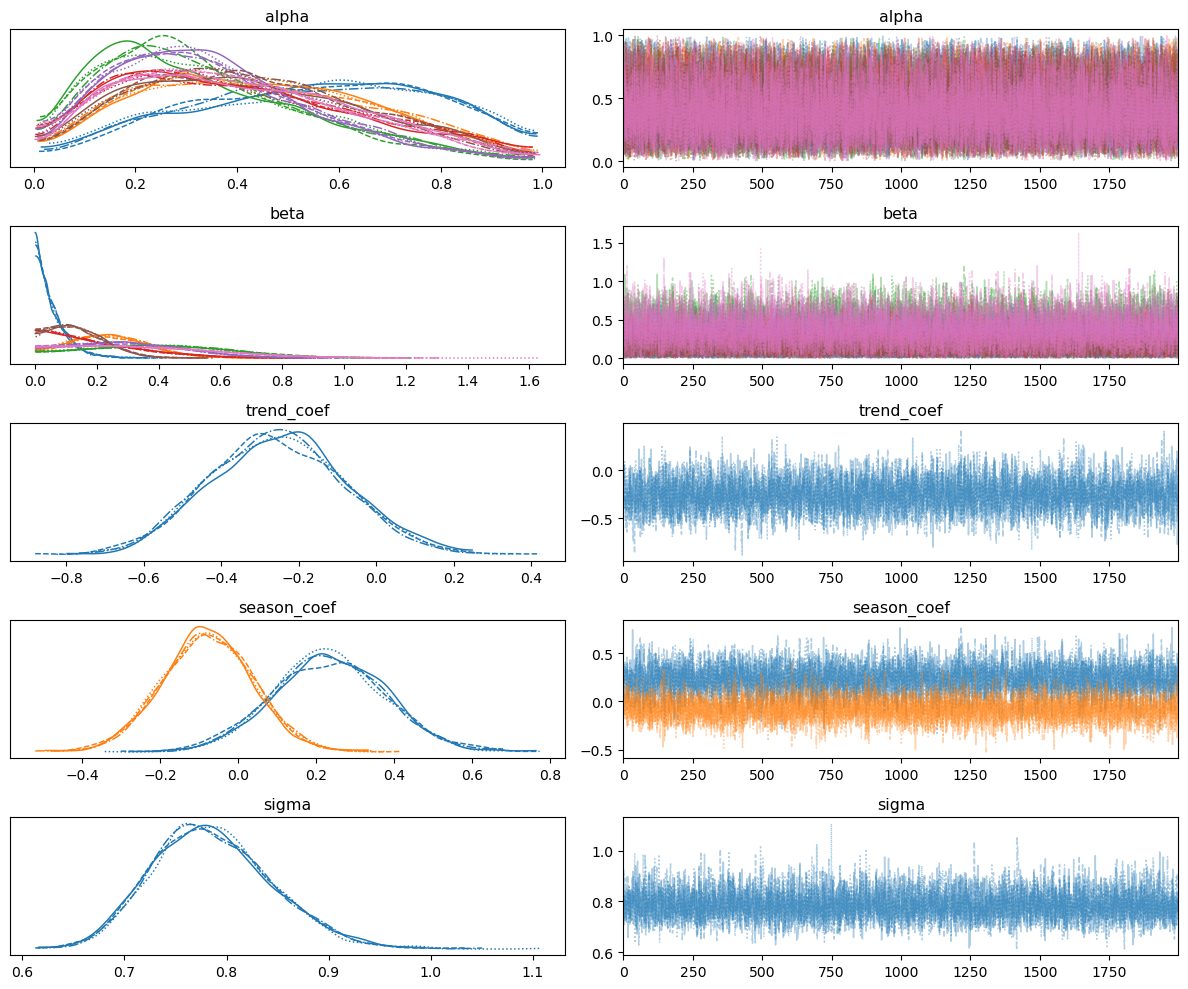

In [16]:
az.plot_trace(trace, var_names=["alpha", "beta", "trend_coef", "season_coef", "sigma"])
plt.tight_layout()
plt.show()

step16:Prior vs posterior

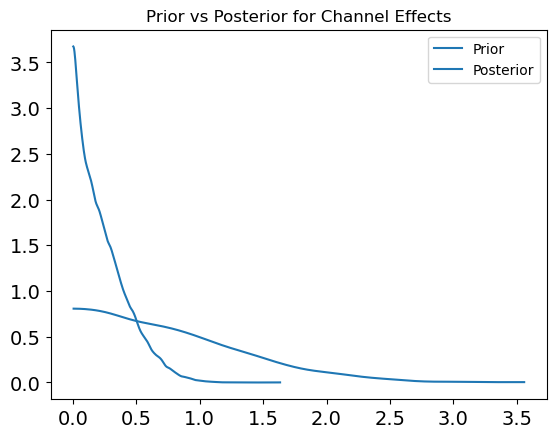

In [17]:
az.plot_dist(
    prior_pred.prior["beta"].values.flatten(),
    label="Prior",
)
az.plot_dist(
    trace.posterior["beta"].values.flatten(),
    label="Posterior",
)
plt.title("Prior vs Posterior for Channel Effects")
plt.legend()
plt.show()

step17:Posterior predictive fit

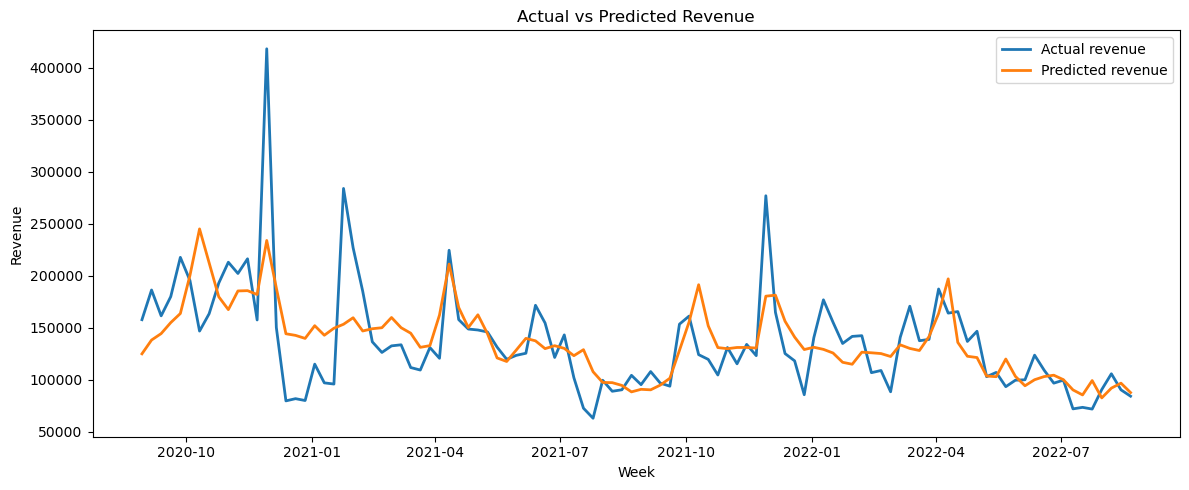

In [18]:
y_pred_scaled = posterior_pred.posterior_predictive["revenue_like"].mean(dim=("chain", "draw")).values
y_pred = y_pred_scaled * y_std + y_mean

plt.figure(figsize=(12, 5))
plt.plot(df["start_of_week"], y, label="Actual revenue", linewidth=2)
plt.plot(df["start_of_week"], y_pred, label="Predicted revenue", linewidth=2)
plt.title("Actual vs Predicted Revenue")
plt.xlabel("Week")
plt.ylabel("Revenue")
plt.legend()
plt.tight_layout()
plt.show()

step18:Model performance

In [19]:
rmse = np.sqrt(mean_squared_error(y, y_pred))
r2 = r2_score(y, y_pred)

print(f"RMSE: {rmse:,.2f}")
print(f"R²:   {r2:.3f}")

RMSE: 37,765.86
R²:   0.442


step19:Channel contributions

In [20]:
alpha_mean = trace.posterior["alpha"].mean(dim=("chain", "draw")).values
beta_mean = trace.posterior["beta"].mean(dim=("chain", "draw")).values

# rebuild adstock outside the model using posterior means
weights = np.array([alpha_mean[i] ** np.arange(max_lag) for i in range(n_channels)])
weights = weights / weights.sum(axis=1, keepdims=True)

adstocked_media_mean = (lagged_media * weights[None, :, :]).sum(axis=2)

# contribution on scaled target
channel_contrib_scaled = adstocked_media_mean * beta_mean[None, :]

# bring back to original revenue scale
channel_contrib = channel_contrib_scaled * y_std

contrib_df = pd.DataFrame(channel_contrib, columns=channel_cols)
contrib_df["start_of_week"] = df["start_of_week"]

contrib_df.head()

,spend_channel_1,spend_channel_2,spend_channel_3,spend_channel_4,spend_channel_5,spend_channel_6,spend_channel_7,start_of_week
0,2655.986972,5202.019773,9000.397336,2981.391661,14666.891910,9957.618925,7477.788952,2020-08-30
1,4118.612221,4455.911606,9099.050535,4968.445784,19550.877813,13912.658214,11664.316750,2020-09-06
2,4366.028136,4158.284772,8017.029203,5606.050135,23822.785257,14382.663039,13387.189951,2020-09-13
3,4100.487981,2887.274349,13233.896895,5466.938308,25886.606421,16216.647841,14899.638008,2020-09-20
4,3810.054168,2874.150031,17299.803917,5542.760294,26915.225282,16796.762930,16194.389123,2020-09-27


step20:Total contribution by channel

In [21]:
total_contrib = contrib_df[channel_cols].sum().sort_values(ascending=False)
total_contrib

spend_channel_3    2.112531e+06
spend_channel_7    1.839612e+06
spend_channel_5    1.547814e+06
spend_channel_2    1.252075e+06
spend_channel_4    9.900302e+05
spend_channel_6    7.166211e+05
spend_channel_1    2.872355e+05
dtype: float64

step21:Plot total contribution

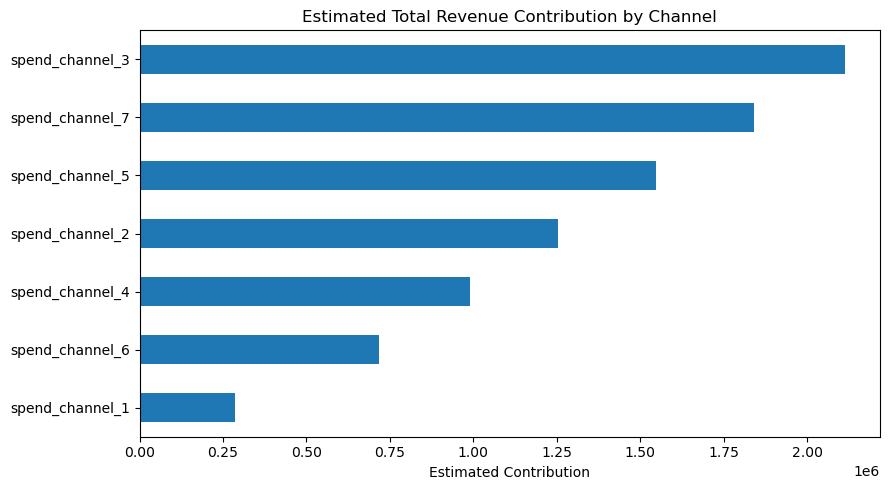

In [22]:
plt.figure(figsize=(9, 5))
total_contrib.sort_values().plot(kind="barh")
plt.title("Estimated Total Revenue Contribution by Channel")
plt.xlabel("Estimated Contribution")
plt.tight_layout()
plt.show()

step22:ROI calculation
(ROI=Total SpendEstimated Revenue Contribution/total spend)

In [23]:
total_spend = df[channel_cols].sum()

roi_df = pd.DataFrame({
    "total_spend": total_spend,
    "estimated_contribution": total_contrib
})

roi_df["ROI"] = roi_df["estimated_contribution"] / roi_df["total_spend"]
roi_df = roi_df.sort_values("ROI", ascending=False)

roi_df

,total_spend,estimated_contribution,ROI
spend_channel_2,35738.66,1.252075e+06,35.034193
spend_channel_1,129542.90,2.872355e+05,2.217300
spend_channel_5,891863.59,1.547814e+06,1.735482
spend_channel_4,719174.22,9.900302e+05,1.376621
spend_channel_6,526624.70,7.166211e+05,1.360781
spend_channel_3,2028746.51,2.112531e+06,1.041299
spend_channel_7,2880942.21,1.839612e+06,0.638545


step23:Plot ROI by channel

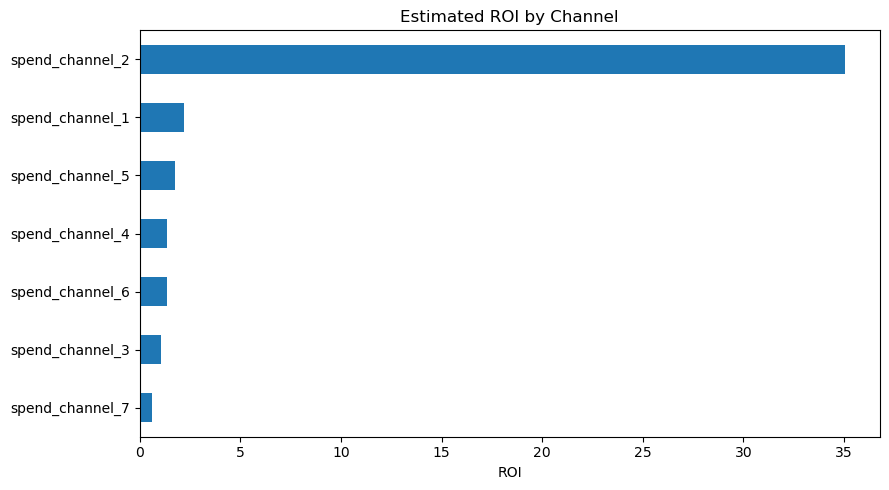

In [24]:
plt.figure(figsize=(9, 5))
roi_df["ROI"].sort_values().plot(kind="barh")
plt.title("Estimated ROI by Channel")
plt.xlabel("ROI")
plt.tight_layout()
plt.show()

step24: weekly contribution chart

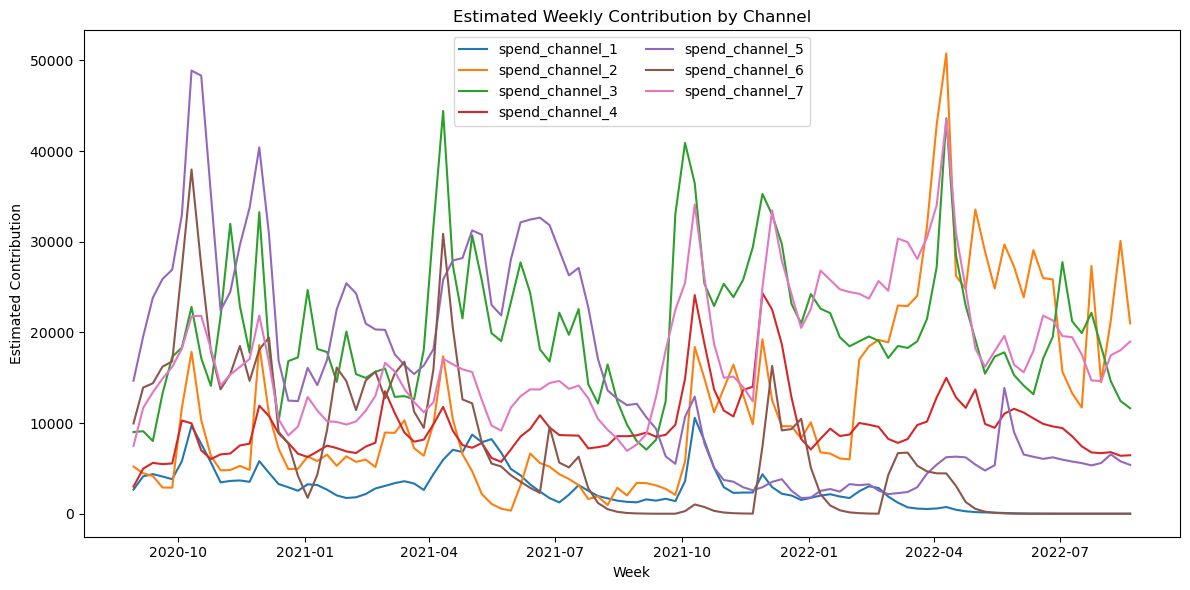

In [25]:
plt.figure(figsize=(12, 6))

for col in channel_cols:
    plt.plot(contrib_df["start_of_week"], contrib_df[col], label=col)

plt.title("Estimated Weekly Contribution by Channel")
plt.xlabel("Week")
plt.ylabel("Estimated Contribution")
plt.legend(ncol=2)
plt.tight_layout()
plt.show()

step25:Campaign period detection

In [26]:
df["total_spend"] = df[channel_cols].sum(axis=1)

campaign_mask = df["total_spend"] > 0

campaign_start_idx = df.index[campaign_mask][0]
campaign_end_idx = df.index[campaign_mask][-1]

campaign_start_date = df.loc[campaign_start_idx, "start_of_week"]
campaign_end_date = df.loc[campaign_end_idx, "start_of_week"]

print("Campaign start:", campaign_start_date.date())
print("Campaign end:", campaign_end_date.date())

Campaign start: 2020-08-30
Campaign end: 2022-08-21


step26: Split into before / during / after campaign

In [27]:
before_campaign = df.loc[:campaign_start_idx - 1].copy()
during_campaign = df.loc[campaign_start_idx:campaign_end_idx].copy()
after_campaign = df.loc[campaign_end_idx + 1:].copy()

print("Weeks before campaign:", len(before_campaign))
print("Weeks during campaign:", len(during_campaign))
print("Weeks after campaign:", len(after_campaign))

Weeks before campaign: 0
Weeks during campaign: 104
Weeks after campaign: 0


step27:Revenue lift since campaign started

In [28]:
avg_rev_before = before_campaign["revenue"].mean() if len(before_campaign) > 0 else np.nan
avg_rev_during = during_campaign["revenue"].mean()

if len(before_campaign) > 0 and avg_rev_before != 0:
    revenue_improvement_pct = ((avg_rev_during - avg_rev_before) / avg_rev_before) * 100
else:
    revenue_improvement_pct = np.nan

print(f"Average revenue before campaign: {avg_rev_before:,.2f}")
print(f"Average revenue during campaign: {avg_rev_during:,.2f}")
print(f"Revenue improvement since campaign started: {revenue_improvement_pct:.2f}%")

Average revenue before campaign: nan
Average revenue during campaign: 136,490.19
Revenue improvement since campaign started: nan%


step28: Plot average revenue by campaign period

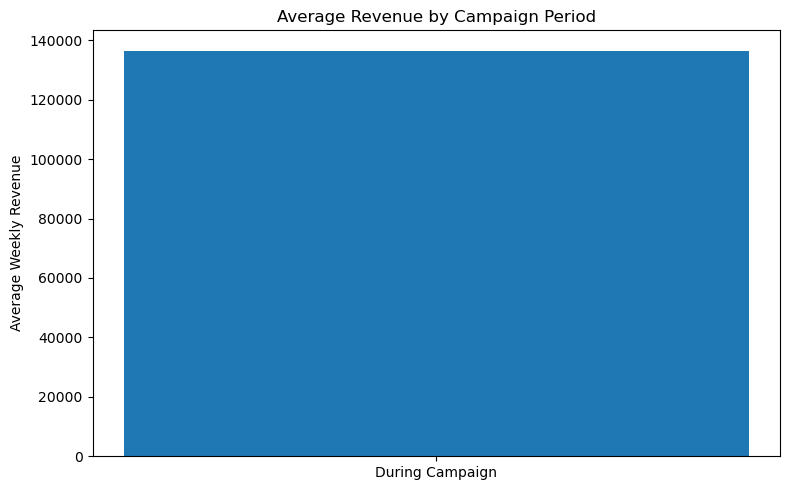

In [29]:
period_labels = []
period_revenue = []

if len(before_campaign) > 0:
    period_labels.append("Before Campaign")
    period_revenue.append(avg_rev_before)

period_labels.append("During Campaign")
period_revenue.append(avg_rev_during)

if len(after_campaign) > 0:
    avg_rev_after = after_campaign["revenue"].mean()
    period_labels.append("After Campaign")
    period_revenue.append(avg_rev_after)

plt.figure(figsize=(8, 5))
plt.bar(period_labels, period_revenue)
plt.title("Average Revenue by Campaign Period")
plt.ylabel("Average Weekly Revenue")
plt.tight_layout()
plt.show()

step29: Total media contribution by week

In [30]:
contrib_df["total_media_contribution"] = contrib_df[channel_cols].sum(axis=1)
contrib_df["start_of_week"] = df["start_of_week"].values

contrib_df.head()

,spend_channel_1,spend_channel_2,spend_channel_3,spend_channel_4,spend_channel_5,spend_channel_6,spend_channel_7,start_of_week,total_media_contribution
0,2655.986972,5202.019773,9000.397336,2981.391661,14666.891910,9957.618925,7477.788952,2020-08-30,51942.095529
1,4118.612221,4455.911606,9099.050535,4968.445784,19550.877813,13912.658214,11664.316750,2020-09-06,67769.872923
2,4366.028136,4158.284772,8017.029203,5606.050135,23822.785257,14382.663039,13387.189951,2020-09-13,73740.030493
3,4100.487981,2887.274349,13233.896895,5466.938308,25886.606421,16216.647841,14899.638008,2020-09-20,82691.489803
4,3810.054168,2874.150031,17299.803917,5542.760294,26915.225282,16796.762930,16194.389123,2020-09-27,89433.145745


step30:final summary table

In [31]:
summary_table = pd.DataFrame({
    "channel": channel_cols,
    "adstock_decay_mean": alpha_mean,
    "effect_mean": beta_mean,
    "total_spend": total_spend.values,
    "estimated_contribution": total_contrib.reindex(channel_cols).values,
    "ROI": roi_df.reindex(channel_cols)["ROI"].values
})

summary_table.sort_values("ROI", ascending=False)

,channel,adstock_decay_mean,effect_mean,total_spend,estimated_contribution,ROI
1,spend_channel_2,0.442961,0.241222,35738.66,1.252075e+06,35.034193
0,spend_channel_1,0.547441,0.054620,129542.90,2.872355e+05,2.217300
4,spend_channel_5,0.349017,0.294875,891863.59,1.547814e+06,1.735482
3,spend_channel_4,0.403032,0.189082,719174.22,9.900302e+05,1.376621
5,spend_channel_6,0.422540,0.136271,526624.70,7.166211e+05,1.360781
2,spend_channel_3,0.334707,0.402822,2028746.51,2.112531e+06,1.041299
6,spend_channel_7,0.400228,0.352209,2880942.21,1.839612e+06,0.638545
